In [1]:
import requests
import pandas as pd

In [2]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)

In [3]:
url = "https://data.gov.il/api/3/action/datastore_search?resource_id=347114f1-1bd7-49b3-848a-582efc46f888"
response = requests.get(url).json()

In [4]:
# The data itself is located under the 'records' key.
df = pd.DataFrame(response['result']['records'])
df.head()

,_id,(אל תשנה) בקשה,(אל תשנה) בדיקת סיכום של שורה,(אל תשנה) השתנה ב:,call_for_proposals,partner_country,category_of_call,call_program,reference_number,budget_year,field,sub_field,merkava_number,proposal_status,institution,researcher_full_name,gender,proposal_title,project_start_date,contract_end_date,budget,currency
0,1,4d851944-fe6d-f011-913c-005056b0a9a4,7sqS41Kw6k/DYcsB7HJpfvGQhJg9xhbjqsT05pAb93wBeP...,2026-02-04 18:53:41,שת''פ גרמניה-טכנולוגיות מים 2025,גרמניה,קול קורא דו לאומי,שיתוף פעולה בינלאומי,9094.0,2025,"מדעי הסביבה, חקלאות ומים",חדשנות בטכנולוגיות מים ומערכות מים,1.001951e+09,מחקר פעיל,אוניברסיטת תל אביב,הדס ממן,נקבה,ניטור מיקרוביולוגי מקוון וחיטוי משולב מתקדם לש...,2025-12-31 00:00:00,2028-12-31 00:00:00,1000385,ILS
1,2,e59516bc-086a-f011-913c-005056b0a9a4,6E5BcxuMPLOAc8cwnA/iApjblGOU9FUJfDSM/MS5KL9B88...,2025-12-29 07:07:03,שת''פ גרמניה-טכנולוגיות מים 2025,גרמניה,קול קורא דו לאומי,שיתוף פעולה בינלאומי,9049.0,2025,"מדעי הסביבה, חקלאות ומים",חדשנות בטכנולוגיות מים ומערכות מים,1.001951e+09,מחקר פעיל,"מוסד הטכניון למחקר ופיתוח בע""מ",תמר סגל-פרץ,נקבה,סילוק בורון ומיקרו-מזהמים ממים באמצעות ממברנו...,2025-12-31 00:00:00,2028-12-31 00:00:00,987850,ILS
2,3,8fe33f84-496c-f011-913c-005056b0a9a4,uK30flU+m5FiLRiGDMfgFEDtcx/LsllcBhAkT//qXCN84H...,2026-02-04 18:53:32,שת''פ גרמניה-טכנולוגיות מים 2025,גרמניה,קול קורא דו לאומי,שיתוף פעולה בינלאומי,9077.0,2025,"מדעי הסביבה, חקלאות ומים",חדשנות בטכנולוגיות מים ומערכות מים,1.001951e+09,מחקר פעיל,מינהל המחקר החקלאי - מרכז וולקני,זיו מורנו,זכר,החדרת אוויר לאקוויפרים ליעול שפילת מי תהום,2025-12-31 00:00:00,2028-12-31 00:00:00,999924,ILS
3,4,2d8ba250-6165-f011-913c-005056b0a9a4,Ob0HySBhSSde2lZg3QYc03QvqvLiSljEWQVrEalqrpzmvY...,2025-12-29 07:02:43,שת''פ גרמניה-טכנולוגיות מים 2025,גרמניה,קול קורא דו לאומי,שיתוף פעולה בינלאומי,8963.0,2025,"מדעי הסביבה, חקלאות ומים",חדשנות בטכנולוגיות מים ומערכות מים,1.001951e+09,מחקר פעיל,האוניברסיטה העברית,אפרת מורין,נקבה,חיזוק החוסן של מערכות מים עירוניות לשינויים אק...,2025-12-31 00:00:00,2028-12-31 00:00:00,999925,ILS
4,5,0d8a174d-ae78-ef11-9137-005056b0a9a4,60QRD6h6sEKg1guEkf/7gkGpPtC13dmb1z6pa6nQbcV8Tl...,2026-03-01 00:59:21,שת''פ בריטניה 2025,בריטניה,קול קורא דו לאומי,שיתוף פעולה בינלאומי,8345.0,2025,כלל המדעים,טכנולוגיות קוונטיות,1.001910e+09,מחקר פעיל,האוניברסיטה העברית,אורי גדרון,זכר,שליטה בפליטת אור מקוטב מעגלי מהתקני CP-OLED על...,2025-07-01 00:00:00,2028-06-30 00:00:00,459885,ILS


In [5]:
import sqlite3
conn = sqlite3.connect(":memory:")

In [6]:
df.to_sql('df', conn, index=False, if_exists="replace")

1649

In [7]:
query = """
SELECT
    budget_year,
    field,
    sub_field,
    institution,
    partner_country,
    category_of_call,
    call_program,
    proposal_status,
    researcher_full_name,
    gender,
    project_start_date,
    contract_end_date,
    budget,
    currency
FROM df
ORDER BY
    budget_year DESC,
    field,
    sub_field,
    institution;
"""

result = pd.read_sql(query, conn)
result

,budget_year,field,sub_field,institution,partner_country,category_of_call,call_program,proposal_status,researcher_full_name,gender,project_start_date,contract_end_date,budget,currency
0,2025,בריאות ורפואה,הזדקנות בריאה,אוניברסיטת בר אילן,,מחקר- ישראל,תשתיות,מחקר פעיל,סול עפרוני,זכר,2025-12-01 00:00:00,2028-11-30 00:00:00,495650,ILS
1,2025,בריאות ורפואה,הזדקנות בריאה,אוניברסיטת חיפה,,מחקר- ישראל,תשתיות,מחקר פעיל,הילה שריג בהט,נקבה,2025-12-01 00:00:00,2028-11-30 00:00:00,488750,ILS
2,2025,בריאות ורפואה,הזדקנות בריאה,אוניברסיטת רייכמן (הבינתחומי הרצליה - IDC),,מחקר- ישראל,תשתיות,מחקר פעיל,לימור שטוץ,נקבה,2025-12-01 00:00:00,2028-11-30 00:00:00,490539,ILS
3,2025,בריאות ורפואה,הזדקנות בריאה,אוניברסיטת תל אביב,,מחקר- ישראל,תשתיות,מחקר פעיל,אלחנן בורנשטין,זכר,2025-12-01 00:00:00,2028-12-30 00:00:00,499905,ILS
4,2025,בריאות ורפואה,הזדקנות בריאה,"המרכז הרפואי ע""ש שיבא",,מחקר- ישראל,תשתיות,מחקר פעיל,אביגיל גושן,נקבה,2025-12-01 00:00:00,2028-11-30 00:00:00,471500,ILS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1644,2019,מדעים מדויקים וטכנולוגיה,תחליפי נפט לתחבורה,,,פרס,פרס,הסתיים,עמנואל פלד,זכר,2019-12-31 00:00:00,2020-12-31 00:00:00,462500,ILS
1645,2019,מדעים מדויקים וטכנולוגיה,תחליפי נפט לתחבורה,,,פרס,פרס,הסתיים,Sang Yup Lee,זכר,2019-12-31 00:00:00,2020-12-31 00:00:00,462500,ILS
1646,2019,מדעים מדויקים וטכנולוגיה,תחליפי נפט לתחבורה,,,פרס,פרס,הסתיים,טלי דקל,נקבה,2019-12-31 00:00:00,2023-12-31 00:00:00,925000,ILS
1647,2019,מדעים מדויקים וטכנולוגיה,תחליפי נפט לתחבורה,,,פרס,פרס,הסתיים,לאונרד שולמן,זכר,2019-12-31 00:00:00,2023-12-31 00:00:00,925000,ILS


In [8]:
query = """
SELECT DISTINCT proposal_status
FROM df;
"""

result = pd.read_sql(query, conn)
result

,proposal_status
0,מחקר פעיל
1,הסתיים


In [9]:
query = """
SELECT 
    currency,
    COUNT(*) AS num_projects,
    SUM(budget) AS total_budget
FROM df
GROUP BY currency;
"""

result = pd.read_sql(query, conn)
result

,currency,num_projects,total_budget
0,ILS,1591,703858563
1,אירו,58,4796963


In [10]:
from IPython.display import display, HTML

# Executive Summary & KPIs
display(HTML("<h2 style='color: #0f172a; font-family: sans-serif; border-bottom: 2px solid #e2e8f0; padding-bottom: 5px;'>Executive Summary & KPIs</h2>"))

# SQL
kpi_query = """
SELECT 
    COUNT(*) AS total_projects,
    SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) AS total_budget_ils,
    COUNT(DISTINCT institution) AS num_institutions,
    COUNT(DISTINCT partner_country) AS num_partner_countries,
    ROUND(AVG(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END), 2) AS avg_budget
FROM df;
"""
kpi_df = pd.read_sql(kpi_query, conn)

total_projects = kpi_df.loc[0, 'total_projects']
total_budget = kpi_df.loc[0, 'total_budget_ils']
num_institutions = kpi_df.loc[0, 'num_institutions']
num_partner_countries = kpi_df.loc[0, 'num_partner_countries']
avg_budget = kpi_df.loc[0, 'avg_budget']

# Percentage of active studies
active_status_query = """
SELECT 
    ROUND(100.0 * SUM(CASE WHEN proposal_status = 'מחקר פעיל' THEN 1 ELSE 0 END) / COUNT(*), 2) AS active_pct
FROM df;
"""
active_pct = pd.read_sql(active_status_query, conn).loc[0, 'active_pct']

# KPIs
display(HTML(f"""
<div style="display: flex; gap: 15px; flex-wrap: wrap; font-family: sans-serif; margin-bottom: 20px;">
    <div style="background-color: #f8fafc; padding: 15px; border-radius: 8px; border: 1px solid #e2e8f0; width: 170px;">
        <span style="color: #64748b; font-size: 0.85em;">Total Budget</span>
        <h3 style="margin: 5px 0 0 0; color: #0f172a;">{total_budget:,.0f}</h3>
    </div>
    <div style="background-color: #f8fafc; padding: 15px; border-radius: 8px; border: 1px solid #e2e8f0; width: 170px;">
        <span style="color: #64748b; font-size: 0.85em;">Total Projects</span>
        <h3 style="margin: 5px 0 0 0; color: #0f172a;">{total_projects:,}</h3>
    </div>
    <div style="background-color: #f8fafc; padding: 15px; border-radius: 8px; border: 1px solid #e2e8f0; width: 170px;">
        <span style="color: #64748b; font-size: 0.85em;">Institutions</span>
        <h3 style="margin: 5px 0 0 0; color: #0f172a;">{num_institutions}</h3>
    </div>
    <div style="background-color: #f8fafc; padding: 15px; border-radius: 8px; border: 1px solid #e2e8f0; width: 170px;">
        <span style="color: #64748b; font-size: 0.85em;">Partner Countries</span>
        <h3 style="margin: 5px 0 0 0; color: #0f172a;">{num_partner_countries}</h3>
    </div>
    <div style="background-color: #f8fafc; padding: 15px; border-radius: 8px; border: 1px solid #e2e8f0; width: 170px;">
        <span style="color: #64748b; font-size: 0.85em;">Avg Budget / Project</span>
        <h3 style="margin: 5px 0 0 0; color: #0f172a;">{avg_budget:,.0f}</h3>
    </div>
    <div style="background-color: #f8fafc; padding: 15px; border-radius: 8px; border: 1px solid #e2e8f0; width: 170px;">
        <span style="color: #64748b; font-size: 0.85em;">Active Studies</span>
        <h3 style="margin: 5px 0 0 0; color: #0f172a;">{active_pct}%</h3>
    </div>
</div>
"""
))

### Research Funding by Institution

In [11]:
query = """
SELECT DISTINCT institution
FROM df;
"""

result = pd.read_sql(query, conn)
result

,institution
0,אוניברסיטת תל אביב
1,"מוסד הטכניון למחקר ופיתוח בע""מ"
2,מינהל המחקר החקלאי - מרכז וולקני
3,האוניברסיטה העברית
4,אוניברסיטת בן גוריון בנגב
5,מכון ויצמן למדע
6,מיגל-מכון למחקר מדעי בגליל
7,"המרכז הרפואי ע""ש שיבא"
8,המרכז הרפואי שערי צדק ירושלים
9,מרכז מחקר ופיתוח עוטף עזה


In [12]:
inst_query = """
SELECT 
    CASE 
        WHEN institution IN ('המרכז הבינתחומי הרצליה', 'אוניברסיטת רייכמן (הבינתחומי הרצליה - IDC)') THEN 'אוניברסיטת רייכמן'
        WHEN institution LIKE '%מיגל%' THEN 'מיגל - מכון למחקר מדעי בגליל'
        WHEN institution LIKE '%אריאל%' THEN 'אוניברסיטת אריאל בשומרון'
        WHEN institution LIKE '%סוראסקי%' THEN 'מרכז רפואי ת"א ע"ש סוראסקי'
        WHEN institution LIKE '%הדסה%' THEN 'קרן מחקרים על יד הסתדרות מדיצינית הדסה'
        WHEN institution LIKE '%מינהל המחקר החקלאי%' THEN 'מינהל המחקר החקלאי'
        WHEN institution LIKE '%המכללה האקדמית עמק יזרעאל%' THEN 'המכללה האקדמית עמק יזרעאל'
        WHEN institution LIKE '%הטכניון%' THEN 'הטכניון'
        WHEN institution LIKE '%משולש%' THEN 'מו"פ משולש'
        WHEN institution LIKE '%קרן מחקרים רפואיים%' THEN 'קרן מחקרים רפואיים'
        ELSE institution 
    END AS institution_cleaned,
    SUM(CASE WHEN proposal_status = 'מחקר פעיל' THEN 1 ELSE 0 END) AS active_projects,
    SUM(CASE WHEN proposal_status != 'מחקר פעיל' THEN 1 ELSE 0 END) AS completed_projects,
    COUNT(*) AS total_projects,
    SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) AS total_budget_ils,
    ROUND(AVG(CASE 
            WHEN proposal_status = 'מחקר פעיל' THEN 
                CASE 
                    WHEN currency = 'אירו' THEN 
                        budget * CASE budget_year
                            WHEN 2019 THEN 3.96
                            WHEN 2020 THEN 3.93
                            WHEN 2021 THEN 3.87
                            WHEN 2022 THEN 3.55
                            WHEN 2023 THEN 4.03
                            WHEN 2024 THEN 4.02
                            WHEN 2025 THEN 4.10
                            ELSE 4.0 
                        END
                    ELSE budget 
                END
        END), 2) AS avg_budget_active,
    ROUND(AVG(CASE 
            WHEN proposal_status != 'מחקר פעיל' THEN 
                CASE 
                    WHEN currency = 'אירו' THEN 
                        budget * CASE budget_year
                            WHEN 2019 THEN 3.96
                            WHEN 2020 THEN 3.93
                            WHEN 2021 THEN 3.87
                            WHEN 2022 THEN 3.55
                            WHEN 2023 THEN 4.03
                            WHEN 2024 THEN 4.02
                            WHEN 2025 THEN 4.10
                            ELSE 4.0 
                        END
                    ELSE budget 
                END
        END), 2) AS avg_budget_completed,
    ROUND(AVG(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END), 2) AS avg_budget_per_project
FROM df
WHERE institution IS NOT NULL AND institution != ''
GROUP BY institution_cleaned
ORDER BY COUNT(*) DESC; 
"""

inst_result = pd.read_sql(inst_query, conn)
inst_result

,institution_cleaned,active_projects,completed_projects,total_projects,total_budget_ils,avg_budget_active,avg_budget_completed,avg_budget_per_project
0,אוניברסיטת בן גוריון בנגב,144,96,240,99241342.92,467935.26,331861.10,413505.60
1,האוניברסיטה העברית,156,76,232,94471128.76,429625.26,361178.80,407203.14
2,הטכניון,154,59,213,94105924.20,467824.67,373913.98,441811.85
3,אוניברסיטת תל אביב,141,63,204,94824470.52,489795.08,408942.29,464825.84
4,אוניברסיטת בר אילן,103,66,169,71271077.08,434951.64,401076.64,421722.35
5,אוניברסיטת אריאל בשומרון,85,20,105,50302632.00,512891.09,335344.45,479072.69
6,אוניברסיטת חיפה,55,19,74,27868116.00,417814.11,257281.05,376596.16
7,מכון ויצמן למדע,45,21,66,34417413.00,521226.13,522011.29,521475.95
8,מינהל המחקר החקלאי,30,10,40,20753476.00,537285.23,463491.90,518836.90
9,קרן מחקרים על יד הסתדרות מדיצינית הדסה,24,2,26,14167353.00,577436.38,154440.00,544898.19


In [13]:
# Low volume, high average budget per project
niche_high_value_query = """
SELECT 
    CASE 
        WHEN institution IN ('המרכז הבינתחומי הרצליה', 'אוניברסיטת רייכמן (הבינתחומי הרצליה - IDC)') THEN 'אוניברסיטת רייכמן'
        WHEN institution LIKE '%מיגל%' THEN 'מיגל - מכון למחקר מדעי בגליל'
        WHEN institution LIKE '%אריאל%' THEN 'אוניברסיטת אריאל בשומרון'
        WHEN institution LIKE '%סוראסקי%' THEN 'מרכז רפואי ת"א ע"ש סוראסקי'
        WHEN institution LIKE '%הדסה%' THEN 'קרן מחקרים על יד הסתדרות מדיצינית הדסה'
        WHEN institution LIKE '%מינהל המחקר החקלאי%' THEN 'מינהל המחקר החקלאי'
        WHEN institution LIKE '%המכללה האקדמית עמק יזרעאל%' THEN 'המכללה האקדמית עמק יזרעאל'
        WHEN institution LIKE '%הטכניון%' THEN 'הטכניון'
        WHEN institution LIKE '%משולש%' THEN 'מו"פ משולש'
        WHEN institution LIKE '%קרן מחקרים רפואיים%' THEN 'קרן מחקרים רפואיים'
        ELSE institution 
    END AS institution_cleaned,
    COUNT(*) AS total_projects,
    SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) AS total_budget_ils,
    ROUND(AVG(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END), 2) AS avg_budget_per_project
FROM df
WHERE institution IS NOT NULL AND institution != ''
GROUP BY institution_cleaned
HAVING COUNT(*) < 20 AND COUNT(*) > 0
ORDER BY avg_budget_per_project DESC
LIMIT 5;
"""

niche_result = pd.read_sql(niche_high_value_query, conn)
niche_result

,institution_cleaned,total_projects,total_budget_ils,avg_budget_per_project
0,"מכללה אקדמית ספיר (ע""ר)",2,3294235.00,1647117.50
1,"מרכז רפואי ת""א ע""ש סוראסקי",9,8847615.00,983068.33
2,אסותא מרכזים רפואיים,1,744604.00,744604.00
3,"מרכז רפואי רמב""ם",7,4896195.00,699456.43
4,"חקר ימים ואגמים לישראל בע""מ",13,8774226.87,674940.53


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

def smart_reverse(text):
    if not isinstance(text, str):
        return text
    has_hebrew = any(0x0590 <= ord(c) <= 0x05FF for c in text)
    if has_hebrew:
        return text[::-1]
    return text

def plot_side_by_side_hue(
    data1,
    x_col1,
    y_col1,
    hue_col1,
    title1,
    xlabel1,
    ylabel1,
    palette1,
    data2,
    x_col2,
    y_col2,
    hue_col2,
    title2,
    xlabel2,
    ylabel2,
    palette2,
):
 
  sns.set_theme(style='whitegrid', font='sans-serif')
  fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=110)

  # Left Chart
  current_palette1 = sns.color_palette(palette1)
  sns.barplot(
      data=data1,
      x=x_col1,
      y=y_col1,
      hue=hue_col1,
      ax=axes[0],
      palette=current_palette1,
      edgecolor='0.2',
      linewidth=0.8,
  )
  axes[0].set_title(title1, fontsize=13, fontweight='bold', pad=15)
  axes[0].tick_params(axis='x', rotation=25)
  axes[0].legend(
      title=hue_col1.replace('_', ' ').title(),
      frameon=True,
      facecolor='white',
      edgecolor='none',
  )
  axes[0].set_xlabel(xlabel1, fontsize=11, labelpad=8)
  axes[0].set_ylabel(ylabel1, fontsize=11, labelpad=8)

  # Right Chart
  current_palette2 = sns.color_palette(palette2)
  sns.barplot(
      data=data2,
      x=x_col2,
      y=y_col2,
      hue=hue_col2,
      ax=axes[1],
      palette=current_palette2,
      edgecolor='0.2',
      linewidth=0.8,
  )
  axes[1].set_title(title2, fontsize=13, fontweight='bold', pad=15)
  axes[1].tick_params(axis='x', rotation=25)
  axes[1].legend(
      title=hue_col2.replace('_', ' ').title(),
      frameon=True,
      facecolor='white',
      edgecolor='none',
  )
  axes[1].set_xlabel(xlabel2, fontsize=11, labelpad=8)
  axes[1].set_ylabel(ylabel2, fontsize=11, labelpad=8)

  for ax in axes:
    sns.despine(ax=ax, top=True, right=True)
    ax.grid(True, linestyle='', alpha=0.6)

  plt.tight_layout()
  plt.show()

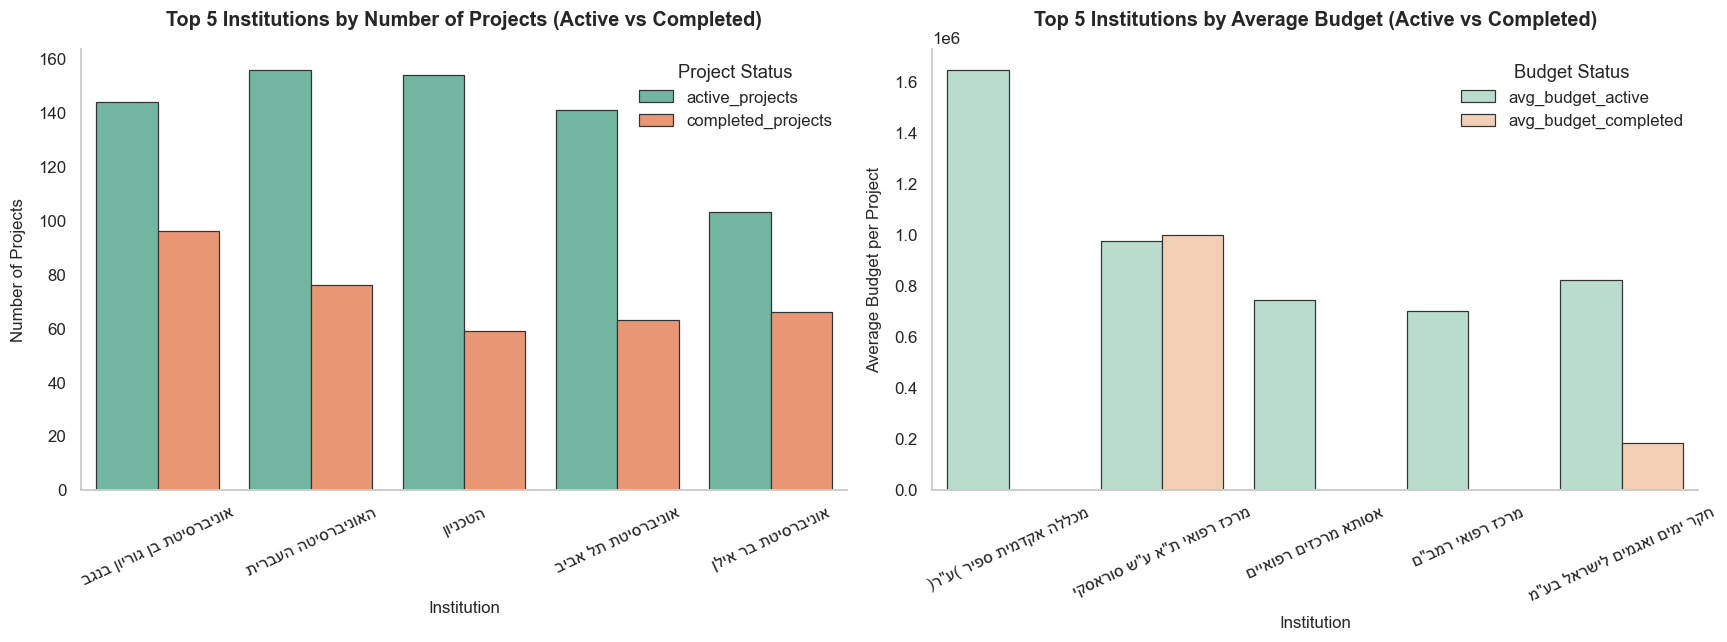

In [15]:
# Research Funding by institutions
def notebook_insight_box(title, text):
    box_html = f"""
    <div style="
        padding: 16px;
        background-color: #f8fafc;
        border-left: 4px solid #2b5c8f;
        border-radius: 6px;
        margin: 15px 0;
        font-family: sans-serif;
        box-shadow: 0 1px 3px rgba(0,0,0,0.05);
    ">
        <span style="font-weight: bold; color: #2b5c8f; font-size: 1.1em;"> {title}</span>
        <p style="margin-top: 8px; color: #334155; line-height: 1.5; font-size: 0.95em;">{text}</p>
    </div>
    """
    display(HTML(box_html))

notebook_insight_box(
    title="Research Funding by Institution (Active vs Completed)",
    text="Question: Which institutions receive the largest share of research funding, and how do active versus completed projects distribute across them?<br>Why it matters: Analyzing project status alongside funding helps determine whether institutional output is dominated by ongoing research or completed milestones."
)

# Data for left graph (number of projects by status)
top_inst_proj = inst_result.sort_values(by='total_projects', ascending=False).head(5).copy()
melted_inst_proj = top_inst_proj.melt(
    id_vars=['institution_cleaned'],
    value_vars=['active_projects', 'completed_projects'],
    var_name='project_status',
    value_name='num_projects'
)
melted_inst_proj['institution_cleaned'] = melted_inst_proj['institution_cleaned'].apply(smart_reverse)

# Data for right graph (average budget by status)
top_inst_budget = inst_result.sort_values(by='avg_budget_per_project', ascending=False).head(5).copy()
melted_inst_budget = top_inst_budget.melt(
    id_vars=['institution_cleaned'],
    value_vars=['avg_budget_active', 'avg_budget_completed'],
    var_name='budget_status',
    value_name='avg_budget'
)
melted_inst_budget['institution_cleaned'] = melted_inst_budget['institution_cleaned'].apply(smart_reverse)

plot_side_by_side_hue(
    melted_inst_proj, 'institution_cleaned', 'num_projects', 'project_status', 
    'Top 5 Institutions by Number of Projects (Active vs Completed)', 'Institution', 'Number of Projects', 'Set2',
    melted_inst_budget, 'institution_cleaned', 'avg_budget', 'budget_status', 
    'Top 5 Institutions by Average Budget (Active vs Completed)', 'Institution', 'Average Budget per Project', 'Pastel2'
)

notebook_insight_box(
    title="Insight:",
    text="Although the five largest universities submit the highest volume of proposals, breaking down the projects by status reveals the proportion of active versus completed initiatives within each leading institution."
)

### How has research funding evolved over the years?

In [16]:
pd.options.display.float_format = '{:,.2f}'.format

# Time-Series
# Research funding evolved over the years
time_query = """
SELECT 
    budget_year,
    COUNT(*) AS total_projects,
    SUM(
        CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END
    ) AS total_budget_ils,
    ROUND(AVG(
        CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END
    ), 2) AS avg_budget_ils
FROM df
WHERE budget_year IS NOT NULL
GROUP BY budget_year
ORDER BY budget_year;
"""

time_result = pd.read_sql(time_query, conn)
time_result

,budget_year,total_projects,total_budget_ils,avg_budget_ils
0,2019,403,"166,699,481.60","413,646.36"
1,2020,46,"13,488,030.00","293,218.04"
2,2021,101,"56,855,372.75","562,924.48"
3,2022,238,"134,890,115.15","566,765.19"
4,2023,240,"105,787,265.00","440,780.27"
5,2024,342,"132,392,717.00","387,113.21"
6,2025,279,"111,899,252.00","401,072.59"


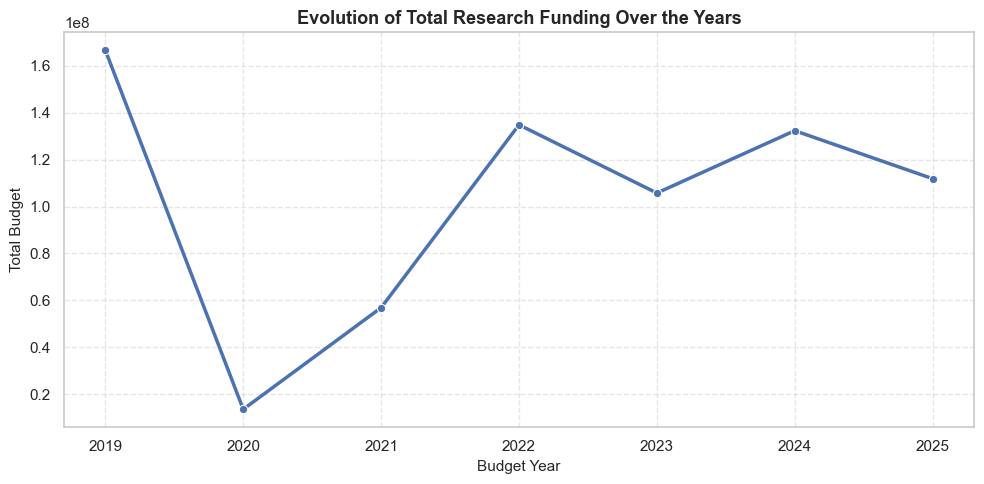

In [17]:
# Budget trend over the years

plt.figure(figsize=(10, 5))
sns.lineplot(data=time_result, x='budget_year', y='total_budget_ils', marker='o', color='b', linewidth=2.5)
plt.title('Evolution of Total Research Funding Over the Years', fontsize=13, fontweight='bold')
plt.xlabel('Budget Year', fontsize=11)
plt.ylabel('Total Budget', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [18]:
growth_query = """
WITH yearly_subfields AS (
    SELECT 
        sub_field,
        MIN(budget_year) AS first_year,
        MAX(budget_year) AS last_year
    FROM df
    WHERE sub_field IS NOT NULL AND sub_field != ''
    GROUP BY sub_field
    HAVING MIN(budget_year) < MAX(budget_year)
),
first_last_budgets AS (
    SELECT 
        y.sub_field,
        y.first_year,
        y.last_year,
        -- Budget in the first year
        (SELECT SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) 
         FROM df d2 WHERE d2.sub_field = y.sub_field AND d2.budget_year = y.first_year) AS budget_first,
        -- Budget in the last year
        (SELECT SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) 
         FROM df d2 WHERE d2.sub_field = y.sub_field AND d2.budget_year = y.last_year) AS budget_last
    FROM yearly_subfields y
)
SELECT 
    sub_field,
    first_year,
    last_year,
    budget_first,
    budget_last,
    (budget_last - budget_first) AS absolute_change,
    ROUND(((budget_last - budget_first) * 100.0 / NULLIF(budget_first, 0)), 2) AS growth_percentage
FROM first_last_budgets
ORDER BY absolute_change DESC
LIMIT 10;
"""

growth_result = pd.read_sql(growth_query, conn)
growth_result

,sub_field,first_year,last_year,budget_first,budget_last,absolute_change,growth_percentage
0,יישומי בינה מלאכותית,2022,2024,1198905,6963579,5764674,480.83
1,הזדקנות בריאה,2022,2025,68000,3932639,3864639,"5,683.29"
2,מחקרים יישומיים פורצי דרך ייחודיים,2022,2023,9035034,12641585,3606551,39.92
3,"פיתוח מכשור, רכיבים, תתי מערכות ומכלולים לפלטפ...",2020,2021,250000,2759999,2509999,"1,004.00"
4,טכנולוגית מים,2022,2024,99992,1897994,1798002,"1,798.15"
5,תשתיות תחבורה,2023,2025,448525,1950211,1501686,334.81
6,מדעי החברה,2019,2024,1589074,2994255,1405181,88.43
7,פיתוח תרופות ותכשירים רפואיים,2022,2023,199959,659127,459168,229.63
8,רעידות אדמה,2019,2025,645035,1092090,447055,69.31
9,מדעים מדוייקים וטכנולוגיה,2020,2023,560000,899645,339645,60.65


In [19]:
notebook_insight_box(
    title="Methodological Note on Growth Analysis:",
    text="To account for variations in active years across different sub-fields, the absolute and percentage budget changes were calculated by comparing each first and most recent year in which the sub-field appears in the dataset. This approach provides a fair representation of funding evolution for emerging fields that did not span the entire 2019–2025 timeline."
)

In [20]:
all_years_query = """
SELECT sub_field, budget_year, SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) AS total_budget_ils
FROM df
WHERE budget_year IS NOT NULL
GROUP BY sub_field, budget_year;
"""

years_df = pd.read_sql(all_years_query, conn)
years_df

,sub_field,budget_year,total_budget_ils
0,"""המלצות בנוגע לאופן בו ניתן לעודד חדשנות בבטיח...",2025,"99,999.00"
1,1. big-data in cleantech technologies או mach...,2020,"799,397.00"
2,2. innovative methods/technologies for monitor...,2020,"799,250.00"
3,Aquaculture and Marine Biotechnology,2021,"755,701.00"
4,Digital Humanities and Social Sciences,2020,"3,986,359.00"
5,Digital healthcare,2021,"755,689.00"
6,STEM,2025,"998,400.00"
7,Science Policy,2020,"173,501.00"
8,אוטומציה,2023,"954,753.00"
9,"אופטיקה מתקדמת, אלקטרוניקה וטכנולוגיות קוונטיו...",2024,"1,195,310.00"


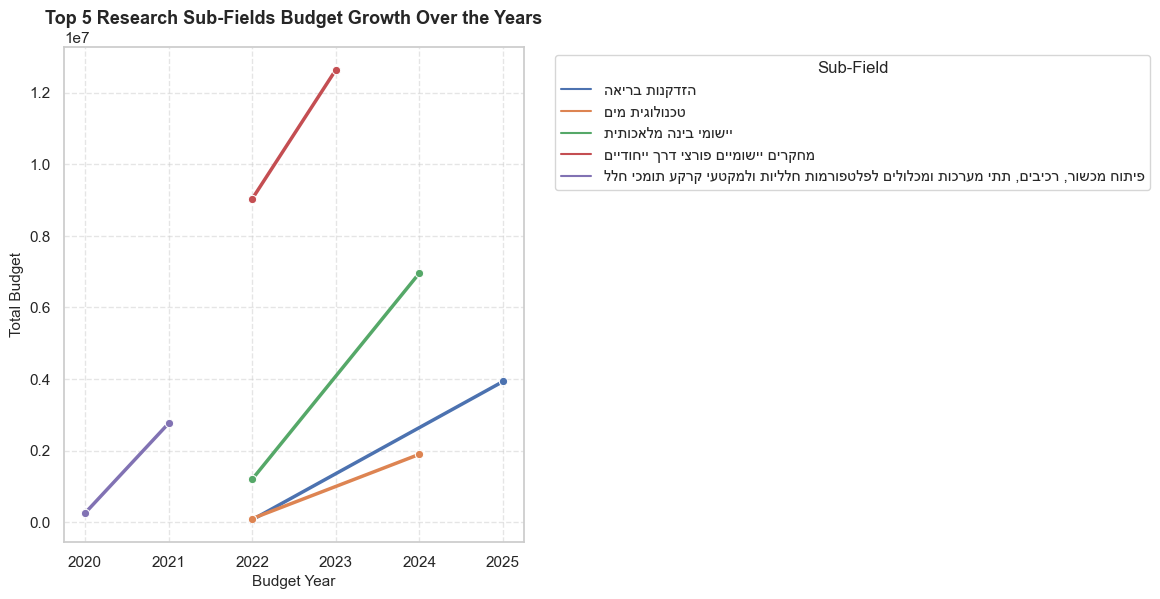

In [21]:
# Sub-Field Funding Growth Analysis

notebook_insight_box(
    title="Sub-Field Funding Growth Analysis",
    text="Question: What are the areas of research that have experienced the most significant budget growth over the years?<br>Why it matters: Tracking budget trends across fields highlights shifting strategic priorities and identifies rapidly growing domains that may represent future investment opportunities."
)

# Top 5 Fields
top_growth_fields = growth_result.head(5)['sub_field'].tolist()
filtered_trend = years_df[years_df['sub_field'].isin(top_growth_fields)].copy()

# Reverse Hebrew for correct right-to-left display
filtered_trend['sub_field'] = filtered_trend['sub_field'].apply(smart_reverse)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_trend, 
    x='budget_year', 
    y='total_budget_ils', 
    hue='sub_field', 
    marker='o', 
    linewidth=2.5
)
plt.title('Top 5 Research Sub-Fields Budget Growth Over the Years', fontsize=13, fontweight='bold')
plt.xlabel('Budget Year', fontsize=11)
plt.ylabel('Total Budget', fontsize=11)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Sub-Field')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

notebook_insight_box(
    title="Insight:",
    text="Certain sub-fields experienced substantial budget scaling over recent years, indicating a strategic shift in national funding priorities.<br>For example, AI applications experienced the largest absolute increase among the analyzed sub-fields, rising from approximately ₪1.2M in 2022 to ₪7.0M in 2024 (+481%). Healthy aging showed the highest percentage growth, increasing from ₪68K in 2022 to ₪3.9M in 2025 (+5,683%). <br>This upward trend suggests increasing governmental emphasis on specific technological or scientific domains."
)

### International collaborations

In [22]:
country_query = """
SELECT 
    partner_country,
    SUM(CASE WHEN proposal_status = 'מחקר פעיל' THEN 1 ELSE 0 END) AS active_projects,
    SUM(CASE WHEN proposal_status != 'מחקר פעיל' THEN 1 ELSE 0 END) AS completed_projects,
    COUNT(*) AS total_projects,
    SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) AS total_budget_ils,
    ROUND(AVG(CASE 
            WHEN proposal_status = 'מחקר פעיל' THEN 
                CASE 
                    WHEN currency = 'אירו' THEN 
                        budget * CASE budget_year
                            WHEN 2019 THEN 3.96
                            WHEN 2020 THEN 3.93
                            WHEN 2021 THEN 3.87
                            WHEN 2022 THEN 3.55
                            WHEN 2023 THEN 4.03
                            WHEN 2024 THEN 4.02
                            WHEN 2025 THEN 4.10
                            ELSE 4.0 
                        END
                    ELSE budget 
                END
        END), 2) AS avg_budget_active,
    ROUND(AVG(CASE 
            WHEN proposal_status != 'מחקר פעיל' THEN 
                CASE 
                    WHEN currency = 'אירו' THEN 
                        budget * CASE budget_year
                            WHEN 2019 THEN 3.96
                            WHEN 2020 THEN 3.93
                            WHEN 2021 THEN 3.87
                            WHEN 2022 THEN 3.55
                            WHEN 2023 THEN 4.03
                            WHEN 2024 THEN 4.02
                            WHEN 2025 THEN 4.10
                            ELSE 4.0 
                        END
                    ELSE budget 
                END
        END), 2) AS avg_budget_completed,
    ROUND(AVG(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END), 2) AS avg_budget_per_project
FROM df
WHERE partner_country IS NOT NULL AND TRIM(partner_country) != ''
GROUP BY partner_country
ORDER BY COUNT(*) DESC;
"""

country_result = pd.read_sql(country_query, conn)
country_result

,partner_country,active_projects,completed_projects,total_projects,total_budget_ils,avg_budget_active,avg_budget_completed,avg_budget_per_project
0,גרמניה,46,58,104,"45,062,519.50","648,598.47","262,534.31","433,293.46"
1,צרפת,33,17,50,"15,783,278.00","312,348.33","322,104.88","315,665.56"
2,איטליה,27,17,44,"16,891,506.00","385,391.33","381,525.88","383,897.86"
3,סין,21,9,30,"11,015,665.00","353,543.19","399,028.67","367,188.83"
4,טיוואן,15,3,18,"4,514,511.00","250,598.13","251,846.33","250,806.17"
5,צ'כיה,9,6,15,"7,164,487.00","379,008.89","625,567.83","477,632.47"
6,רוסיה,0,14,14,"6,280,767.00",NaN,"448,626.21","448,626.21"
7,הודו,10,0,10,"3,396,011.00","339,601.10",NaN,"339,601.10"
8,ארגנטינה,7,3,10,"676,153.00","67,885.57","66,984.67","67,615.30"
9,קפריסין,9,0,9,"3,471,559.00","385,728.78",NaN,"385,728.78"


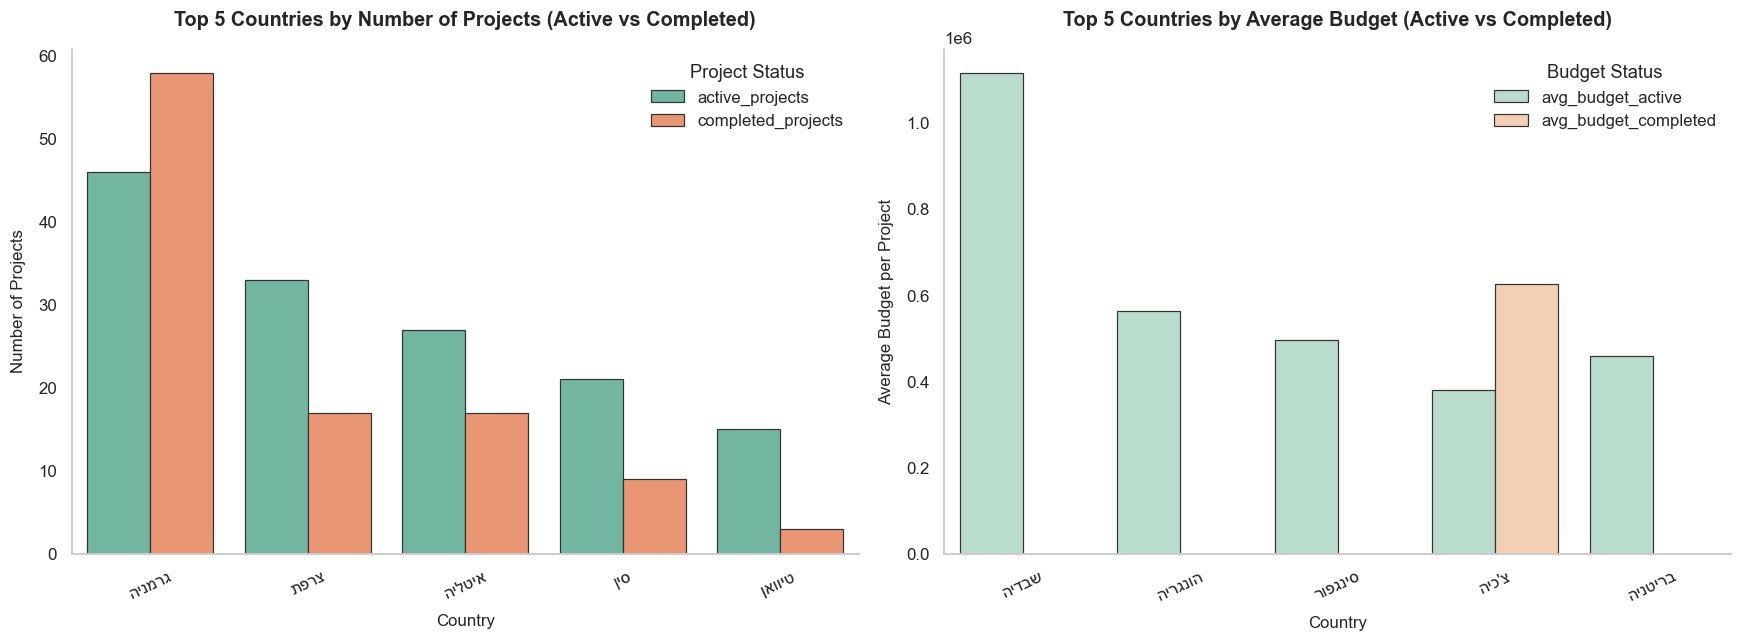

In [23]:
notebook_insight_box(
    title="International Research Collaborations (Active vs Completed)",
    text="Question: How do active and completed projects break down among the top collaborating partner countries?<br>Why it matters: Differentiating between ongoing and completed international projects highlights the longevity and current state of global research partnerships."
)

# Data for left graph (number of projects by status)
top_country_proj = country_result.sort_values(by='total_projects', ascending=False).head(5).copy()
melted_country_proj = top_country_proj.melt(
    id_vars=['partner_country'],
    value_vars=['active_projects', 'completed_projects'],
    var_name='project_status',
    value_name='num_projects'
)
melted_country_proj['partner_country'] = melted_country_proj['partner_country'].apply(smart_reverse)

# Data for right graph (average budget by status)
top_country_budget = country_result.sort_values(by='avg_budget_per_project', ascending=False).head(5).copy()
melted_country_budget = top_country_budget.melt(
    id_vars=['partner_country'],
    value_vars=['avg_budget_active', 'avg_budget_completed'],
    var_name='budget_status',
    value_name='avg_budget'
)
melted_country_budget['partner_country'] = melted_country_budget['partner_country'].apply(smart_reverse)

plot_side_by_side_hue(
    melted_country_proj, 'partner_country', 'num_projects', 'project_status', 
    'Top 5 Countries by Number of Projects (Active vs Completed)', 'Country', 'Number of Projects', 'Set2',
    melted_country_budget, 'partner_country', 'avg_budget', 'budget_status', 
    'Top 5 Countries by Average Budget (Active vs Completed)', 'Country', 'Average Budget per Project', 'Pastel2'
)

notebook_insight_box(
    title="Insight:",
    text="""Germany acts as a primary pillar of joint research in terms of sheer volume (104 projects with ₪46.1M in total funding), ensuring broad-based bilateral scientific engagement. In contrast, Sweden demonstrates a high-budget niche strategy maintaining a small cohort of collaborative projects (8 active studies, 0 completed) backed by an exceptionally high average per-project budget of ₪1.12M. This illustrates how some lower-volume partnerships can involve substantially higher average project budgets, particularly in specialized research domains."""
)

In [24]:
field_analysis_query = """
SELECT 
    partner_country,
    sub_field,
    COUNT(sub_field) AS total_projects,
    SUM(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END) AS total_budget_ils,
    ROUND(AVG(CASE 
            WHEN currency = 'אירו' THEN 
                budget * CASE budget_year
                    WHEN 2019 THEN 3.96
                    WHEN 2020 THEN 3.93
                    WHEN 2021 THEN 3.87
                    WHEN 2022 THEN 3.55
                    WHEN 2023 THEN 4.03
                    WHEN 2024 THEN 4.02
                    WHEN 2025 THEN 4.10
                    ELSE 4.0 
                END
            ELSE budget 
        END), 2) AS avg_budget_per_project
FROM df
WHERE partner_country IN ('גרמניה', 'שבדיה')
GROUP BY partner_country, sub_field
ORDER BY partner_country, total_budget_ils DESC;
"""

df_field_analysis = pd.read_sql(field_analysis_query, conn)
df_field_analysis

,partner_country,sub_field,total_projects,total_budget_ils,avg_budget_per_project
0,גרמניה,חקר הסרטן,30,"14,666,105.00","488,870.17"
1,גרמניה,סוללות,4,"5,008,185.00","1,252,046.25"
2,גרמניה,חדשנות בטכנולוגיות מים ומערכות מים,4,"3,988,084.00","997,021.00"
3,גרמניה,שימוש חוזר במים בחקלאות,4,"3,903,750.00","975,937.50"
4,גרמניה,גישות חדשניות לניהול נכסים של תשתיות מים; טיפו...,4,"3,550,012.00","887,503.00"
5,גרמניה,סרטן,24,"3,082,320.00","128,430.00"
6,גרמניה,"חקלאות, סביבה ומים",15,"2,784,806.64","185,653.78"
7,גרמניה,כימות והפחתת ההשפעה של מזהמים עמידים ו/או מיקר...,3,"2,658,115.75","886,038.58"
8,גרמניה,טכנולוגיות מים,8,"1,617,524.88","202,190.61"
9,גרמניה,ניהול משאבי מים,2,"1,261,329.75","630,664.88"


In [25]:
notebook_insight_box(
    title="Insight:",
    text="A deep-dive into sub-fields reveals distinct strategic allocations: <br>Sweden's high-budget niche strategy is consistently concentrated in advanced high-tech and deep-science domains (such as advanced materials, molecular biology, and biotechnology) with standardized high per-project budgets (~₪1.12M). <br>In contrast, Germany operates as a broad-spectrum scientific partner, driving high overall volume heavily anchored in medical research (e.g., cancer research totaling ~₪14.7M across 30 projects) while selectively scaling up high-investment initiatives in specialized technical domains like batteries and water technologies."
)